# 1 · Counting Photons: What is Quantum Light?

**Lecture · Monday July 27, 11:30–12:30 · Tim Thomay**

### Learning objectives

After this lecture you can:

1. explain why photon-**number statistics** distinguish light sources that have *identical* average intensity,
2. write down and *recognize* the photon number distribution $P(n)$ for **coherent**, **thermal**, and **Fock** states, at any brightness,
3. compute and interpret the **Mandel $Q$ parameter** as a witness of non-classical light,
4. estimate **shot noise** in real measurements — from grainy night photos to why LIGO runs 200 kW of laser power and still had to squeeze the vacuum.

*References: Fox, "Quantum Optics" Ch. 5 [Fox2006]; Gerry & Knight Ch. 3 [GerryKnight2005]; original papers in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, factorial
import qutip

# Course plot style: readable in the back row of the lecture hall.
plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)  # reproducible "experiments"
print("qutip", qutip.__version__)

qutip 5.3.0


## 1.0 · A short history of a reluctant idea (1900–1926)

The photon was forced on physics over the objections of nearly everyone involved — including its inventors:

| year | who | what |
|---|---|---|
| 1900 | **Planck** | quantizes the *exchange* of energy between light and matter, $E = h\nu$ — "an act of desperation" to fit the blackbody spectrum. He does not believe light itself is grainy. |
| 1905 | **Einstein** | takes the quanta seriously: light *consists* of independent energy quanta [Einstein1905]. Explains the photoelectric effect; this — not relativity — is his Nobel citation (1921). |
| 1909 | **G.I. Taylor** | photographs a diffraction pattern with light so feeble ("a candle burning at a distance slightly exceeding a mile") that quanta pass one at a time — the interference pattern survives [Taylor1909]. We repeat his experiment on a quantum processor on Wednesday. |
| 1909 | **Einstein again** | derives the energy fluctuations of blackbody radiation: a *sum of two terms*, one wave-like, one particle-like. Photon statistics is born in that formula — both terms reappear today in $(\Delta n)^2$. |
| 1916 | **Millikan** | spends a decade trying to *disprove* the light quantum, confirms the photoelectric equation precisely [Millikan1916] — and still calls the theory "wholly untenable". |
| 1923 | **Compton** | X-ray quanta carry momentum $h\nu/c$ [Compton1923]. Resistance collapses. |
| 1926 | **G.N. Lewis** | coins the word *photon* [Lewis1926] (in a paper whose theory was wrong; the name outlived it). |

Then for thirty years almost nobody asked the next question: *how do photons arrive?* One by one? In clumps? At random? That question — **photon statistics** — created modern quantum optics (Tuesday's story), and it starts here.

## 1.1 · Three light sources walk into a bar…

Take three sources, all attenuated to the **same average power** — say $\bar n = 4$ photons per detection window:

* a **laser** → coherent light,
* a **filtered lamp** / starlight → thermal (*chaotic*) light,
* an ideal **single-photon gun** fired 4 times per window → Fock states.

A classical power meter *cannot tell them apart*. But light arrives in discrete photons, and a photon-counting detector sees three completely different streams of clicks.

**The photon number distribution $P(n)$ — the probability of finding $n$ photons in a measurement window — is the fingerprint of a light source.** Today we learn to read the fingerprint; the rest of the course is about measuring it (Tue) and engineering it (Wed).

## 1.2 · One field mode = one harmonic oscillator

Maxwell's equations in a box separate the field into independent modes; each mode (one frequency $\omega$, one direction, one polarization) is mathematically a harmonic oscillator. Canonical quantization gives, per mode,

$$\hat H = \hbar\omega\left(\hat a^\dagger \hat a + \tfrac12\right),\qquad
[\hat a, \hat a^\dagger] = 1,\qquad \hat n = \hat a^\dagger \hat a ,$$

and the electric field of the mode is, up to the mode function,

$$\hat E \;\propto\; \hat X \cos\omega t + \hat P \sin\omega t,\qquad
\hat X = \tfrac{\hat a + \hat a^\dagger}{\sqrt2},\quad \hat P = \tfrac{\hat a - \hat a^\dagger}{i\sqrt2}.$$

The **quadratures** $\hat X, \hat P$ are the "position and momentum" of light: $\Delta X\,\Delta P \ge \tfrac12$. Even the vacuum has $\Delta X = \Delta P = 1/\sqrt2$ — **zero-point fluctuations**. Hold that thought: vacuum noise will turn out to be a *physical actor* (it limits LIGO — section 1.7 — and it seeds photon-pair generation on Wednesday).

**Fock (number) states** $|n\rangle$ are the eigenstates of $\hat n$ — exactly defined photon number:

$$\hat n |n\rangle = n|n\rangle, \qquad \hat a|n\rangle = \sqrt{n}\,|n-1\rangle, \qquad \hat a^\dagger|n\rangle = \sqrt{n+1}\,|n+1\rangle.$$

They are the natural basis for photon counting — but **no natural light source emits Fock states.** What nature hands us is built *from* them:

| state | definition | $P(n)$ | who emits it |
|---|---|---|---|
| **Fock** $\lvert n_0\rangle$ | $\hat n$ eigenstate | $\delta_{n,n_0}$ | nobody, without effort (→ Wed) |
| **coherent** $\lvert\alpha\rangle$ | $\hat a\lvert\alpha\rangle = \alpha\lvert\alpha\rangle$ | $e^{-\bar n}\,\dfrac{\bar n^{\,n}}{n!}$ — **Poisson**, $\bar n = \lvert\alpha\rvert^2$ | ideal laser |
| **thermal** $\hat\rho_{\rm th}$ | max. entropy at fixed $\bar n$ | $\dfrac{\bar n^{\,n}}{(1+\bar n)^{n+1}}$ — **Bose–Einstein** | lamp, star, LED, ASE |

About the **coherent state**, the hero of the classical world: it is the *displaced vacuum*, $|\alpha\rangle = \hat D(\alpha)|0\rangle$ — the same minimal-uncertainty blob, pushed out to amplitude $|\alpha|$ in phase space. Its Poissonian statistics are those of **independent random events**: laser photons carry no memory of one another. (The laser: 1960, Maiman. That laser light is *statistically* different from lamp light — not just brighter — was only proven by photon counting in 1965/66, by Arecchi and others [Arecchi1965].)

The **thermal state** is the opposite character: maximum-entropy *mixed* state — many independent emitters with random phases. A star is thermal, and (Wednesday's spoiler) so is one arm of a photon-pair source when you ignore the other.

## 1.3 · The fingerprints: $P(n)$ at equal brightness

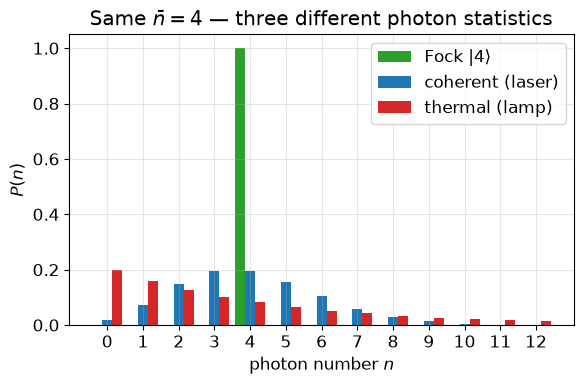

In [2]:
# Build the three states in QuTiP and read off P(n).
# QuTiP represents states in a truncated Fock space of dimension N:
# make N comfortably larger than any photon number we care about.
N = 100         # Fock-space cutoff; thermal states have long tails, and a
                # too-small cutoff silently biases variances - be generous
nbar = 4.0      # mean photon number, identical for all three sources

psi_fock = qutip.fock(N, int(nbar))          # |4>
psi_coh = qutip.coherent(N, np.sqrt(nbar))   # |alpha|^2 = nbar -> alpha = 2
rho_thermal = qutip.thermal_dm(N, nbar)      # mixed state, needs a density matrix

def photon_number_distribution(state) -> np.ndarray:
    """P(n) = diagonal of the density matrix in the Fock basis.

    Parameters
    ----------
    state : qutip.Qobj
        A ket or a density matrix of a single field mode.

    Returns
    -------
    np.ndarray
        P(n) for n = 0 .. N-1 (dimensionless probabilities, sum ~ 1).
    """
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

fig, ax = plt.subplots()
n_axis = np.arange(13)
width = 0.28
for i, (label, state, color) in enumerate([
        ("Fock $|4\\rangle$", psi_fock, "tab:green"),
        ("coherent (laser)", psi_coh, "tab:blue"),
        ("thermal (lamp)", rho_thermal, "tab:red")]):
    P = photon_number_distribution(state)[:len(n_axis)]
    ax.bar(n_axis + (i - 1) * width, P, width, label=label, color=color)
ax.set_xlabel("photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_title(r"Same $\bar{n} = 4$ — three different photon statistics")
ax.set_xticks(n_axis)
ax.legend()
plt.tight_layout()
plt.show()

Read the fingerprints:

* **Fock**: a single spike. Zero uncertainty in photon number — maximal "quantumness" in $n$.
* **Coherent**: Poisson, peaked *near* $\bar n$ with width $\sqrt{\bar n}$ — independent random arrivals, like raindrops on a roof.
* **Thermal**: monotonic geometric decay — **$n=0$ is always the most likely outcome**, at any brightness (!), with a long tail: huge fluctuations. Photons arrive in *bunches*.

### …and across brightness

The same three families at $\bar n = 0.2$, $4$, and $25$ — because your intuition should work at *every* power level:

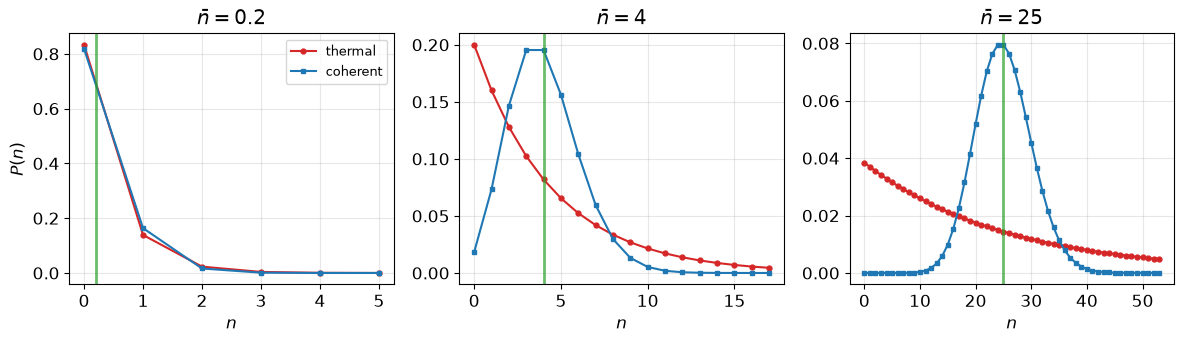

In [3]:
# The same fingerprints from the few-photon to the semi-classical regime.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, nb_ in zip(axes, [0.2, 4.0, 25.0]):
    nmax = int(nb_ + 5 * np.sqrt(nb_) + 4)
    n = np.arange(nmax)
    P_poisson = np.exp(-nb_) * nb_**n / factorial(n)
    P_thermal = nb_**n / (1 + nb_)**(n + 1)
    ax.plot(n, P_thermal, "o-", ms=3.5, color="tab:red", label="thermal")
    ax.plot(n, P_poisson, "s-", ms=3.5, color="tab:blue", label="coherent")
    ax.axvline(nb_, color="tab:green", lw=2, alpha=0.7,
               label=f"Fock $|{nb_:g}\\rangle$" if nb_ == int(nb_) else None)
    ax.set_title(f"$\\bar{{n}} = {nb_:g}$")
    ax.set_xlabel("$n$")
axes[0].set_ylabel("$P(n)$")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

Three regimes worth internalizing:

* **$\bar n \ll 1$** (single-photon regime, QKD, single emitters): coherent and thermal look *almost identical* — both are dominated by $P(0) \approx 1$, $P(1) \approx \bar n$. Statistics alone can barely distinguish them here; you need *correlations* (tomorrow!).
* **$\bar n \sim$ a few**: the sweet spot where the fingerprints are most visible — this is where we simulate.
* **$\bar n \gg 1$** (classical regime): Poisson → narrow Gaussian, relative width $1/\sqrt{\bar n} \to 0$ (the classical "steady beam"); thermal *stays* ragged — its relative fluctuations never die. A thermal field of macroscopic brightness still flickers by 100%.

## 1.4 · The same three states in phase space

$P(n)$ throws away all phase information. The full single-mode picture lives in phase space $(X, P)$ as the **Wigner function** — a quasi-probability distribution: correct marginals on both quadratures, but allowed to go **negative**, and *negativity is an unforgeable signature of non-classicality*.

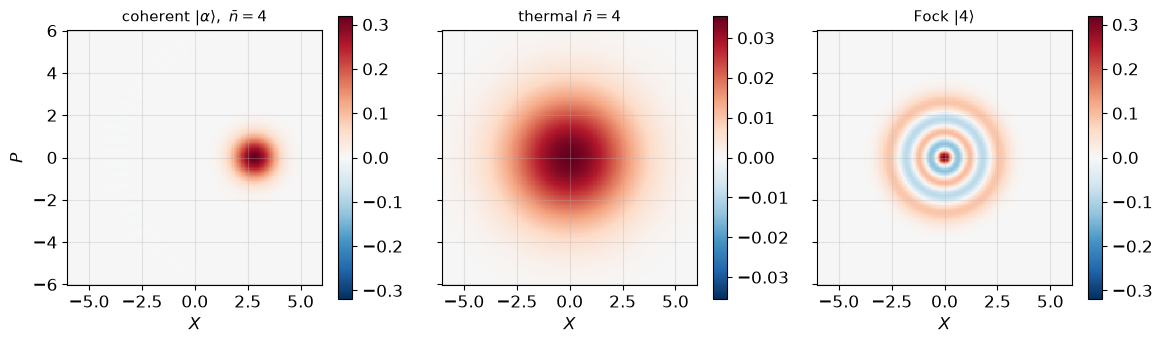

most negative Wigner value of |4>: -0.1292  <- impossible classically


In [4]:
# Wigner functions: coherent & thermal look classical; Fock states do not.
xvec = np.linspace(-6, 6, 201)
states_w = [(r"coherent $|\alpha\rangle,\ \bar{n}=4$", qutip.coherent(N, 2.0)),
            (r"thermal $\bar{n}=4$", qutip.thermal_dm(N, 4.0)),
            (r"Fock $|4\rangle$", qutip.fock(N, 4))]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, (label, st) in zip(axes, states_w):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    im = ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].set_ylabel("$P$")
plt.tight_layout()
plt.show()

W_fock = qutip.wigner(qutip.fock(N, 4), xvec, xvec)
print(f"most negative Wigner value of |4>: {W_fock.min():.4f}  <- impossible classically")

* **Coherent**: a minimum-uncertainty Gaussian blob displaced from the origin — a classical "amplitude + phase" arrow, plus unavoidable vacuum fuzz. (Phase and photon number are conjugate: sharp phase ⇒ fuzzy $n$.)
* **Thermal**: a fat Gaussian *at the origin* — random amplitude, completely random phase. Positive everywhere: classical noise.
* **Fock**: concentric rings diving **below zero**. Sharp photon number, *no phase at all*. No classical field ensemble can produce this.

Keep the triptych in mind: *coherent and thermal states are classical lookalikes; Fock states are the genuinely quantum objects.*

## 1.5 · Quantifying the width: variance and the Mandel $Q$ parameter

$$(\Delta n)^2_{\rm Fock} = 0, \qquad (\Delta n)^2_{\rm coh} = \bar n, \qquad (\Delta n)^2_{\rm th} = \bar n + \bar n^2.$$

Look at the thermal result: this is **Einstein's 1909 fluctuation formula** — a *particle* term $\bar n$ (shot noise) plus a *wave* term $\bar n^2$ (classical intensity beats). Wave–particle duality, hiding in a variance.

Mandel's $Q$ [Mandel1979] measures the deviation from pure shot noise:

$$\boxed{\;Q = \frac{(\Delta n)^2 - \bar n}{\bar n}\;}\qquad
\begin{cases}
Q = 0 & \text{Poissonian (coherent)}\\
Q > 0 & \text{super-Poissonian (thermal: } Q = \bar n)\\
-1 \le Q < 0 & \text{sub-Poissonian (Fock: } Q = -1)
\end{cases}$$

**Why we care:** any *classical* intensity ensemble gives $Q \ge 0$ — classical fields can only *add* noise on top of shot noise (two-line Cauchy–Schwarz proof tomorrow). Measuring $Q < 0$ is **proof of non-classical light** — predicted for resonance fluorescence by Mandel [Mandel1979], first observed by Short & Mandel in 1983 [ShortMandel1983]. (Its cousin *antibunching* came first, in 1977, from the fluorescence of a sodium atomic beam with on average a single atom in view [Kimble1977] — tomorrow's story.)

In [5]:
def mandel_Q(state) -> float:
    """Mandel Q parameter of a single-mode state.

    Q = (variance(n) - <n>) / <n>. Q=0 Poissonian, Q<0 sub-Poissonian
    (non-classical), Q>0 super-Poissonian.
    """
    N_dim = state.shape[0]
    n_op = qutip.num(N_dim)
    mean = qutip.expect(n_op, state)
    var = qutip.expect(n_op**2, state) - mean**2
    return (var - mean) / mean

for label, state in [("Fock |4>  ", psi_fock),
                     ("coherent  ", psi_coh),
                     ("thermal   ", rho_thermal)]:
    print(f"{label}: Q = {mandel_Q(state):+.3f}")

Fock |4>  : Q = -1.000
coherent  : Q = +0.000
thermal   : Q = +4.000


## 1.6 · Shot noise in the real world

Poissonian counting means $\Delta N = \sqrt{\bar N}$, so every intensity measurement with $\bar N$ detected photons has

$$\text{signal-to-noise ratio} \;\le\; \frac{\bar N}{\sqrt{\bar N}} = \sqrt{\bar N}
\qquad\Longleftrightarrow\qquad
\text{relative noise} = \frac{1}{\sqrt{\bar N}} .$$

That innocent square root runs half of experimental physics. Worked numbers:

| measurement | photons collected $\bar N$ | shot-noise floor $1/\sqrt{\bar N}$ |
|---|---|---|
| phone photo pixel, night mode | $\sim 10^2$ | **10%** — that's the grain you see |
| phone photo pixel, sunlight | $\sim 10^4$ | 1% — smooth |
| 1 mW laser pointer, 1 s integration | $2.7\times10^{15}$ | $2\times10^{-8}$ |
| fluorescence of *one* molecule, 1 ms bin | $\sim 10^2$ | 10% — single-molecule biophysics fights this daily |
| LIGO circulating beam, 10 ms | $\sim 10^{22}$ | $10^{-11}$ — and *still not good enough* (next section) |

Photon counting is one of the very few games where the noise floor is set by *how much light you collect*, not by your amplifier — and improving it means either **more photons** ($\sqrt{N}$: painful) or **better statistics than Poisson** ($Q<0$ or squeezing: quantum optics' sales pitch).

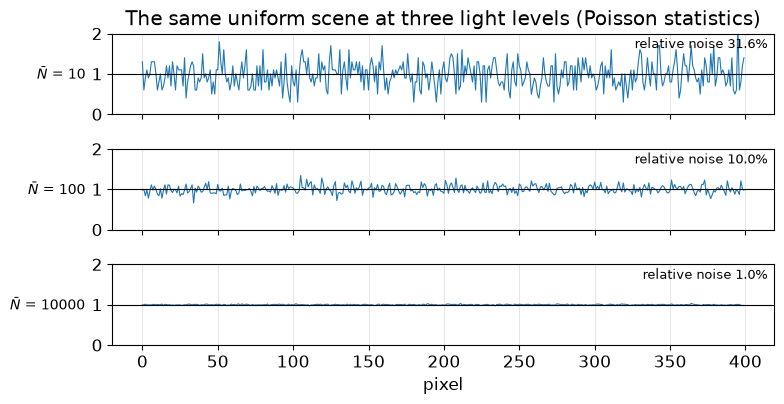

In [6]:
# Shot noise you have personally seen: photon counts across an 'image' row.
# A uniform gray scene photographed at three light levels.
pixels = 400
fig, axes = plt.subplots(3, 1, figsize=(8, 4.2), sharex=True)
for ax, Nbar in zip(axes, [10, 100, 10_000]):
    counts = rng.poisson(Nbar, pixels)
    ax.plot(counts / Nbar, lw=0.8)
    ax.axhline(1, color="k", lw=0.8)
    ax.set_ylim(0, 2)
    ax.set_ylabel(f"$\\bar N$ = {Nbar}", rotation=0, ha="right", va="center",
                  fontsize=10)
    ax.text(0.99, 0.82, f"relative noise {1/np.sqrt(Nbar):.1%}",
            transform=ax.transAxes, ha="right", fontsize=9)
axes[-1].set_xlabel("pixel")
axes[0].set_title("The same uniform scene at three light levels (Poisson statistics)")
plt.tight_layout()
plt.show()

## 1.7 · Case study: LIGO, the strong laser, and the vacuum that enters through the dark port

A gravitational-wave interferometer measures a *phase difference* between two 4 km arms. At the shot-noise limit, the phase uncertainty per measurement is

$$\Delta\varphi_{\rm shot} \simeq \frac{1}{\sqrt{\bar N}},$$

and LIGO needs $\Delta\varphi \sim 10^{-11}$ — displacement sensitivity of $10^{-18}$ m, a thousandth of a proton radius — to hear black holes collide [Abbott2016]. Hence design decision #1: **as strong a laser as the optics survive** — hundreds of kW circulating in the arms, because every factor 100 in power buys only a factor 10 in phase noise.

But brute force saturated. The next insight is pure quantum optics [Caves1981]: analyze *where the noise actually comes from*, and it is **not** the laser. The interferometer's beamsplitter has **two** input ports — the laser enters one, and the other, the "dark port"… is empty. Empty means **vacuum state**, and vacuum fluctuations ($\Delta X = \Delta P = 1/\sqrt2$, section 1.2) enter there, beat against the laser field, and produce exactly the shot noise at the readout.

Caves' 1981 proposal: *replace* the vacuum at the dark port with **squeezed vacuum** — a state with $\Delta X < 1/\sqrt2$ in the measured quadrature (at the price of $\Delta P > 1/\sqrt2$, as Heisenberg collects his fee). Nothing about the laser changes; you improve the interferometer by upgrading *the state of nothing*.

It took ~30 years of squeezer engineering [Schnabel2017]; since 2019 LIGO and Virgo run with squeezed light injected into the dark port, gaining up to ~3 dB of sensitivity — a **40–50% increase in the expected detection rate** [Tse2019]. GEO600 holds the kilometer-scale record: 6.0 dB of quantum-noise reduction [Lough2021]. This is photon statistics as an astronomy instrument.

**Open-quantum-systems dictionary** (for this school's shared language): the interferometer is a system coupled to the *continuum of vacuum modes* — a zero-temperature bath. Shot noise is bath-induced noise entering through a specific port, and squeezing is **bath engineering**: you do not touch the system, you prepare the *environment* in a nonclassical state. You will meet the same move as "squeezed reservoirs" in the open-systems lectures of this school.

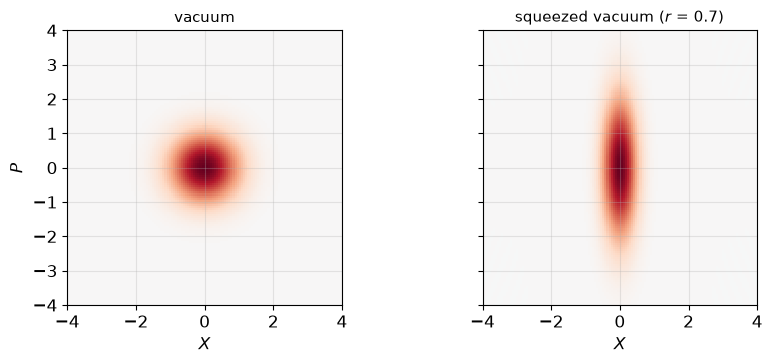

vacuum          : dX = 0.707, dP = 0.707, dX*dP = 0.500
squeezed vacuum : dX = 0.351, dP = 1.424, dX*dP = 0.500

P(n) of squeezed vacuum: [0.797 0.    0.146 0.    0.04  0.    0.012 0.   ]


In [7]:
# The state of nothing, upgraded: vacuum vs squeezed vacuum.
r = 0.7                                    # squeezing parameter (~6 dB)
vac = qutip.fock(N, 0)
sq_vac = qutip.squeeze(N, r) * vac         # squeezed vacuum state

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (label, st) in zip(axes, [("vacuum", vac),
                                  (f"squeezed vacuum ($r$ = {r})", sq_vac)]):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
axes[0].set_ylabel("$P$")
plt.tight_layout()
plt.show()

for label, st in [("vacuum          ", vac), ("squeezed vacuum ", sq_vac)]:
    dX = np.sqrt(qutip.variance(qutip.position(N), st))
    dP = np.sqrt(qutip.variance(qutip.momentum(N), st))
    print(f"{label}: dX = {dX:.3f}, dP = {dP:.3f}, dX*dP = {dX*dP:.3f}")

# Bonus fingerprint: squeezed vacuum contains only EVEN photon numbers -
# photons are born in pairs. Remember this on Wednesday (SPDC!).
P_sq = photon_number_distribution(sq_vac)[:8]
print("\nP(n) of squeezed vacuum:", np.array2string(P_sq, precision=3))

Two things to take away from the printout:

* the squeezed vacuum indeed has $\Delta X < \Delta X_{\rm vac}$ with $\Delta X\,\Delta P$ still $\ge \tfrac12$ — noise is *redistributed*, not destroyed;
* its $P(n)$ contains **only even photon numbers**: squeezed light is made of photon *pairs*. The two-mode version of this state is exactly what a down-conversion crystal emits — Wednesday we will herald single photons out of it.

### "But isn't a Fock state squeezed?" — no, and the difference matters

A persistent misconception, worth killing with numbers: because Fock states are exotic and squeezed states are exotic, the two get conflated — *"a Fock state is a squeezed state"*. It is not. **Squeezed** means: noise in *some* quadrature **below the vacuum level** $\Delta X_{\rm vac} = 1/\sqrt2$. Compute the quadrature noise of every state we met today:

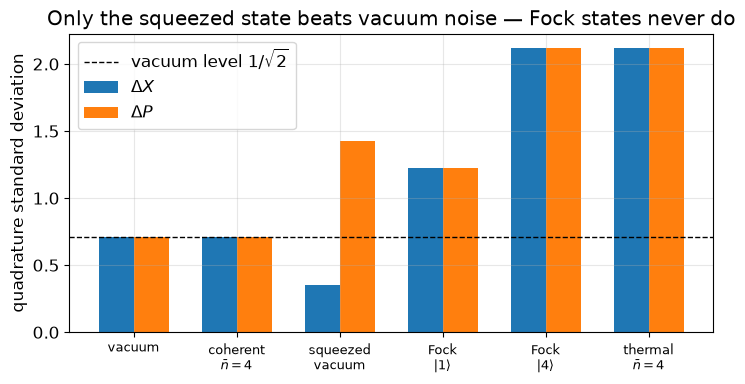

Fock |4>: dX = dP = 2.121 - identical to thermal nbar=4 (2.121)!


In [8]:
# Is anything here actually squeezed? Quadrature noise vs the vacuum level.
states_q = [("vacuum", qutip.fock(N, 0)),
            ("coherent\n" + r"$\bar{n}=4$", qutip.coherent(N, 2.0)),
            ("squeezed\nvacuum", qutip.squeeze(N, 0.7) * qutip.fock(N, 0)),
            ("Fock\n" + r"$|1\rangle$", qutip.fock(N, 1)),
            ("Fock\n" + r"$|4\rangle$", qutip.fock(N, 4)),
            ("thermal\n" + r"$\bar{n}=4$", qutip.thermal_dm(N, 4.0))]

x_op, p_op = qutip.position(N), qutip.momentum(N)
dX = [np.sqrt(qutip.variance(x_op, st)) for _, st in states_q]
dP = [np.sqrt(qutip.variance(p_op, st)) for _, st in states_q]

xpos = np.arange(len(states_q))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(xpos - 0.17, dX, 0.34, label=r"$\Delta X$", color="tab:blue")
ax.bar(xpos + 0.17, dP, 0.34, label=r"$\Delta P$", color="tab:orange")
ax.axhline(1 / np.sqrt(2), color="k", ls="--", lw=1,
           label=r"vacuum level $1/\sqrt{2}$")
ax.set_xticks(xpos, [n for n, _ in states_q], fontsize=9)
ax.set_ylabel("quadrature standard deviation")
ax.set_title("Only the squeezed state beats vacuum noise — Fock states never do")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fock |4>: dX = dP = {dX[4]:.3f} - identical to thermal nbar=4"
      f" ({dX[5]:.3f})!")

Read the bars:

* only the **squeezed vacuum** dips below the dashed vacuum line — in one quadrature, paying for it in the other;
* **Fock states sit *above* vacuum noise in every quadrature**, $\Delta X = \Delta P = \sqrt{n + \tfrac12}$ — their Wigner rings lie *outside* the vacuum disk in all directions, with no preferred axis to squeeze along (a state of definite $n$ has no phase, section 1.4!);
* the punchline: $|4\rangle$ and the *thermal* state with $\bar n = 4$ have **identical quadrature noise** — second moments cannot tell our most quantum state from our most classical one.

So the two flagship non-classical states are non-classical in *orthogonal* ways:

| state | quadrature noise vs vacuum | Gaussian? | Wigner | non-classicality witness |
|---|---|---|---|---|
| coherent | equal | yes | positive | — (the classical reference) |
| thermal | above | yes | positive | — |
| **squeezed vacuum** | **below** (one axis) | yes | positive | sub-vacuum noise (2nd moments) |
| **Fock** | above (all axes) | **no** | **negative** | Wigner negativity (beyond 2nd moments) |

Squeezing lives entirely in second moments, so a **homodyne** measurement sees it (that is LIGO's detection chain). Fock-state quantumness is invisible to second moments — you need **photon counting** to see it. Two different windows into the quantum world; this course looks through the second one.

## 1.8 · Why you have never *seen* thermal statistics (multimode detection)

Objection from the back row: *"Sunlight is thermal and my photodiode integrates sunlight — where is the Bose–Einstein distribution with its wild fluctuations?"*

Resolution: Bose–Einstein statistics hold **per mode**. A real detector integrates over $M$ modes — $M \approx \frac{\text{detection time}}{\text{coherence time}} \times \frac{\text{detection area}}{\text{coherence area}} \times 2$ polarizations. Sunlight has femtosecond coherence: even a 1 ns detector sees $M \sim 10^6$.

Summing $M$ independent thermal modes (total mean $\bar n$) gives the **negative binomial** distribution with

$$Q = \frac{\bar n}{M} \;\xrightarrow{\;M\to\infty\;}\; 0 .$$

The bunching washes out as $1/M$: thermal light *hides* its statistics from slow, fat detectors. This is why nobody stumbled on photon bunching for 50 years — and why its discovery (HBT, 1956, with a narrowband mercury line and fast electronics — tomorrow's opening story) shocked the physics community.

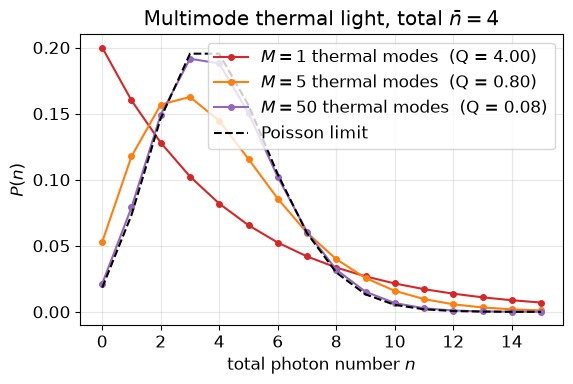

In [9]:
# Multimode thermal light: Bose-Einstein morphs into Poisson as M grows.
def negative_binomial_P(n: np.ndarray, nbar: float, M: int) -> np.ndarray:
    """P(n) for M equally bright thermal modes with total mean nbar."""
    x = nbar / M
    return comb(n + M - 1, n) * x**n / (1 + x)**(n + M)

n_axis = np.arange(16)
fig, ax = plt.subplots()
for M, color in [(1, "tab:red"), (5, "tab:orange"), (50, "tab:purple")]:
    ax.plot(n_axis, negative_binomial_P(n_axis, 4.0, M), "o-", ms=4,
            color=color, label=f"$M = {M}$ thermal modes  (Q = {4.0/M:.2f})")
ax.plot(n_axis, np.exp(-4.0) * 4.0**n_axis / factorial(n_axis), "k--",
        label="Poisson limit")
ax.set_xlabel("total photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_title(r"Multimode thermal light, total $\bar{n} = 4$")
ax.legend()
plt.tight_layout()
plt.show()

## 1.9 · What the detector actually sees: click streams

$P(n)$ is an abstraction — a photon counter produces a **stream of time tags**. A 2 ms simulated recording of our three sources (same average rate!); tomorrow you analyze exactly such data quantitatively.

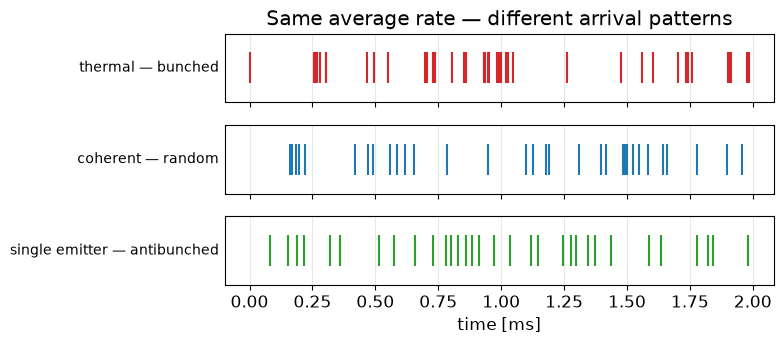

In [10]:
# Simulate 'click' arrival times (simplified versions of data/make_timetags.py).
rate = 20e3        # mean detected rate [clicks/s]
T_show = 2e-3      # displayed time window [s]

# coherent light: memoryless Poisson process
t_coherent = np.sort(rng.uniform(0, T_show, rng.poisson(rate * T_show)))

# thermal light: intensity fluctuates on the coherence time scale (bunching)
tau_c = 50e-6                                  # coherence time [s]
n_slots = int(T_show / tau_c)
intensity = rng.exponential(1.0, n_slots)      # single-mode thermal: I ~ exp
counts = rng.poisson(rate * tau_c * intensity)
t_thermal = np.sort(np.concatenate(
    [(k + rng.uniform(size=c)) * tau_c for k, c in enumerate(counts)]))

# single emitter: a dead time after every photon (antibunching)
gaps = rng.exponential(1 / rate, int(3 * rate * T_show)) + 20e-6  # 20 us dead time
t_emitter = np.cumsum(gaps)
t_emitter = t_emitter[t_emitter < T_show]

fig, axes = plt.subplots(3, 1, figsize=(8, 3.6), sharex=True)
for ax, (label, t, color) in zip(axes, [
        ("thermal — bunched", t_thermal, "tab:red"),
        ("coherent — random", t_coherent, "tab:blue"),
        ("single emitter — antibunched", t_emitter, "tab:green")]):
    ax.eventplot(t * 1e3, colors=color, linelengths=0.8)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
axes[-1].set_xlabel("time [ms]")
axes[0].set_title("Same average rate — different arrival patterns")
plt.tight_layout()
plt.show()

Thermal clicks come in **clusters** (bunching), coherent clicks are **patternless**, and the single emitter keeps a minimum distance between clicks (**antibunching**) — it must be re-excited before it can emit again.

## 1.10 · Where do these states live in the lab?

| source | state | $Q$ | typical $\bar n$ per mode |
|---|---|---|---|
| laser above threshold | coherent | $0$ | anything you like |
| laser *at* threshold | partly thermal | $>0$ | Arecchi's 1965 counting experiment [Arecchi1965] |
| lamp, LED, star, ASE | thermal | $\bar n$ | $\ll 1$ (optical), $\gg 1$ (radio) |
| attenuated laser pulse | still coherent! | $0$ | $\sim 0.1$ (used in QKD) |
| squeezed vacuum (LIGO dark port) | pairs only, even $n$ | $>0$ (!) | $\ll 1$ |
| single atom / molecule / quantum dot / NV center | approx. $\lvert 1\rangle$ | $\to -1$ | $\le 1$ |
| heralded SPDC (→ Lecture 6) | $\lvert 1\rangle$, $\lvert 2\rangle$, … | $\to -1$ | $\le 1$ |

Two traps worth remembering:

* **Attenuating a laser never makes single photons.** Loss thins Poisson into sparser Poisson — $Q$ stays 0. A "0.1 photons per pulse" laser still has two-photon events; quantum key distribution had to invent decoy states because of this.
* **Thermal light doesn't mean "hot".** It means *chaotic*: many independent emitters with random phases.

## 1.11 · Check your understanding

1. Where exactly in Einstein's fluctuation formula $(\Delta n)^2 = \bar n + \bar n^2$ do "wave" and "particle" live? Which term survives for coherent light, and why?
2. You attenuate the Fock state $\lvert 4\rangle$ with 50% loss. Is the output still a Fock state? Still sub-Poissonian? *(You simulate exactly this after lunch.)*
3. Why is $Q = -1$ the most negative value possible?
4. A source emits $\lvert 1 \rangle$ with probability $p$, vacuum otherwise. Compute $Q$. Is a lossy single-photon source still non-classical?
5. Note the table above: squeezed vacuum has $Q > 0$ — super-Poissonian! — yet it is deeply non-classical (Wigner negativity in the two-mode version, LIGO improvement). Moral: $Q < 0$ is *sufficient* for non-classicality, not *necessary*. Which witness catches squeezed vacuum?
6. Estimate the number of detected modes $M$ for (a) sunlight on a 100 ps-gated detector of 100 µm diameter, (b) a single-mode-fiber-coupled, 1 nm-filtered source on an SNSPD. For which one could you hope to see bunching?
7. LIGO doubles its circulating power. By how much does the shot-noise-limited strain sensitivity improve? How many dB of squeezing achieve the same?

**This afternoon (14:00):** we build all of today's states in code, *live* — sampling detector clicks, plotting Wigner functions, watching loss eat the quantumness ([`02_HandsOn_SimulatingPhotonStatistics`](02_HandsOn_SimulatingPhotonStatistics.ipynb)). No laptop needed — bring predictions. **Tonight, the week's only evening task (~20 min):** the setup notebook [`00_Setup_GitHub_Codespaces`](00_Setup_GitHub_Codespaces.ipynb) — fork, Codespace, one test cell — so that from tomorrow you can work hands-on.